## Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import pickle
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Deep Learning Libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from google.colab import files

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


##Kaggle Setup & Data Loading

In [ ]:
# Install kagglehub
#!pip install kagglehub[pandas-datasets]

import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# This tells Colab where your Kaggle key is
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

print("Environment ready!")

Environment ready!


### Load Dataset & Data Cleaning

In [ ]:
# Set the specific file name
file_path = "WELFake_Dataset.csv"

print("Downloading and loading dataset from Kaggle...")
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "saurabhshahane/fake-news-classification",
  file_path,
)

# Data Cleaning immediately after loading
df.fillna('', inplace=True)
df['total_content'] = df['title'] + " " + df['text']

print("Success! First 5 records:")
print(df.head())

/tmp/ipykernel_10752/3969403616.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 92.1M/92.1M [00:03<00:00, 29.5MB/s]

Extracting zip of WELFake_Dataset.csv...


Success! First 5 records:
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                      
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  \
0  No comment is expected from Barack Obama Membe...      1   
1     Did they post their votes for Hillary already?      1   
2   Now, most of the demonstrators gathered last ...      1   
3  A dozen politically active pastors came here f...      0   
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1   

                                       total_content  
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...  
1     Did they post their votes for Hillary already?  
2  UNBELIEVABLE! OBAM

#### Text Preprocessing and vectorization

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

print("Cleaning text...")
df['clean_content'] = df['total_content'].apply(preprocess_text)

# Step 7: TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000)
X_tfidf = tfidf.fit_transform(df['clean_content'])
y = df['label']

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning text...


### TF-IDF & Classical Data Split (Classical Model)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We limit features to 10,000 for a strong, manageable baseline
tfidf = TfidfVectorizer(max_features=10000)
X_tfidf = tfidf.fit_transform(df['clean_content'])
y = df['label']

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")

TF-IDF Matrix Shape: (72134, 10000)


### LSTM Data Prep & Architecture

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
max_words = 15000
max_len = 300

# Tokenization
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_content'])
sequences = tokenizer.texts_to_sequences(df['clean_content'])

# Padding
X_padded = pad_sequences(sequences, maxlen=max_len)

# New Split for LSTM (Using the padded sequences)
X_train_ls, X_temp_ls, y_train_ls, y_temp_ls = train_test_split(X_padded, y, test_size=0.20, random_state=42)
X_val_ls, X_test_ls, y_val_ls, y_test_ls = train_test_split(X_temp_ls, y_temp_ls, test_size=0.50, random_state=42)

# Build the Architecture
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("LSTM Model Architecture built and compiled.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Model Architecture built and compiled.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_performance(model, X_data, y_true, model_name, is_deep_learning=False):
    # Handle the difference between Classical (predict) and Deep Learning (predict > 0.5)
    if is_deep_learning:
        y_pred_prob = model.predict(X_data)
        y_pred = (y_pred_prob > 0.5).astype("int32")
    else:
        y_pred = model.predict(X_data)

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return {"acc": acc, "f1": f1}

### Training & Prediction

Training LSTM on GPU...
Epoch 1/3
451/451 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.9059 - loss: 0.2429 - val_accuracy: 0.9290 - val_loss: 0.1958
Epoch 2/3
451/451 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.9492 - loss: 0.1420 - val_accuracy: 0.9486 - val_loss: 0.1526
Epoch 3/3
451/451 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.9532 - loss: 0.1299 - val_accuracy: 0.9375 - val_loss: 0.1831
226/226 ━━━━━━━━━━━━━━━━━━━━ 47s 208ms/step

--- LSTM Neural Network Evaluation ---
Accuracy: 0.9401 | Precision: 0.9712 | Recall: 0.9093 | F1: 0.9392

Detailed Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3543
           1       0.97      0.91      0.94      3671

    accuracy                           0.94      7214
   macro avg       0.94      0.94      0.94      7214
weighted avg       0.94      0.94      0.94      7214



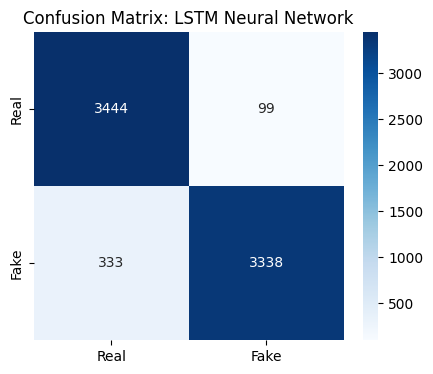

In [ ]:
print("Training LSTM on GPU...")
# We use the Validation Set (X_val_ls) during training to monitor performance
history = model.fit(X_train_ls, y_train_ls, epochs=3, batch_size=128, validation_data=(X_val_ls, y_val_ls))

# Use the same evaluation function (set is_deep_learning=True)
lstm_results = evaluate_model_performance(model, X_test_ls, y_test_ls, "LSTM Neural Network", is_deep_learning=True)

### Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split into 80% Train and 20% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_tfidf, y, test_size=0.20, random_state=42)

# Split Temp into 50% Val and 50% Test (Results in 10% each of total data)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Classical Split -> Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Classical Split -> Train: 57707, Val: 7213, Test: 7214


#### Trying with Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# max_iter=1000 ensures the math has enough 'time' to find the best fit
lr_model = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)
print("Training complete!")

Training Logistic Regression...
Training complete!


### Evaluation Function

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_performance(model, X_data, y_true, model_name, is_deep_learning=False):
    # Handle the difference between Classical (predict) and Deep Learning (predict > 0.5)
    if is_deep_learning:
        y_pred_prob = model.predict(X_data)
        y_pred = (y_pred_prob > 0.5).astype("int32")
    else:
        y_pred = model.predict(X_data)

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return {"acc": acc, "f1": f1}

### Evaluate Classical Model


--- Logistic Regression Evaluation ---
Accuracy: 0.9577 | Precision: 0.9563 | Recall: 0.9608 | F1: 0.9586

Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      3543
           1       0.96      0.96      0.96      3671

    accuracy                           0.96      7214
   macro avg       0.96      0.96      0.96      7214
weighted avg       0.96      0.96      0.96      7214



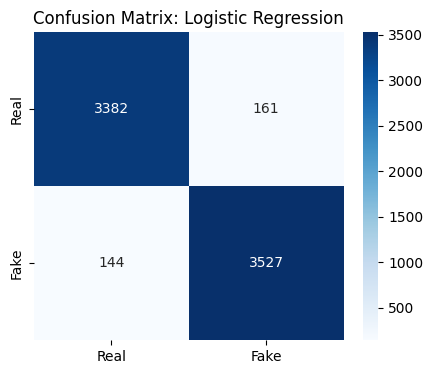

In [ ]:
lr_results = evaluate_model_performance(lr_model, X_test, y_test, "Logistic Regression")

### Predict on New Articles & Export the Pipeline

In [ ]:
import pickle
from google.colab import files
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Define the Prediction Function ---
def predict_news(news_text):
    """
    Takes a string of news, cleans it, and returns the model's verdict.
    """
    # Ensure we use the correct cleaning function from Step 6
    cleaned = preprocess_text(news_text)

    # Convert text to the sequence of integers the model understands
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)

    # Get the raw probability from the sigmoid output
    prediction = model.predict(padded, verbose=0)[0][0]

    # Determine result based on 0.5 threshold
    result = "FAKE" if prediction > 0.5 else "REAL"
    confidence = prediction if result == "FAKE" else (1 - prediction)

    print("-" * 30)
    print(f"VERDICT: {result}")
    print(f"CONFIDENCE: {confidence * 100:.2f}%")
    print("-" * 30)

# --- 2. Live Test with an Article ---
print("Testing prediction on a sample article...")
sample_news = "BREAKING: NASA confirms that the moon is actually a giant space station built by ancient civilizations."
predict_news(sample_news)

# --- 3. Export for Web App Deployment ---
print("\nExporting model and tokenizer for VS Code...")

# Save the Deep Learning model weights and architecture
model.save('welfake_lstm_model.h5')

# Save the Tokenizer (Critical: This is the dictionary for your model)
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Trigger the download to your local Windows machine
files.download('welfake_lstm_model.h5')
files.download('tokenizer.pkl')

print("\nDOWNLOAD STARTED. Move these files to your 'saved_models' folder in VS Code.")

Testing prediction on a sample article...


------------------------------
VERDICT: FAKE
CONFIDENCE: 99.29%
------------------------------

Exporting model and tokenizer for VS Code...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DOWNLOAD STARTED. Move these files to your 'saved_models' folder in VS Code.
